# WPM Visual Explainer

This notebook is a CPU-quick visual explanation of the Wave Propagation Method (WPM) used in this repository.

The goal is not to build a realistic atomistic electron-microscopy specimen. Instead, we use synthetic two-index media so the algorithmic difference is easy to see:

- Angular spectrum multislice applies a local phase screen, then propagates through vacuum with the exact free-space dispersion.
- WPM treats each slice as locally homogeneous and propagates with a local refractive index.
- The WPM advantage becomes visible when lateral refractive-index variation, finite slice thickness, and high-angle components are all present.

The refractive-index contrast and low beam energy below are deliberately pedagogical. They amplify the difference so the diagrams are readable.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import sys
from pathlib import Path

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "wide_angle_propagation").exists():
        ROOT = candidate
        break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from wide_angle_propagation.propagation_methods import (
    Propagator,
    angular_spectrum_propagation_kernel,
    energy2wavelength,
    wpm_step_adaptive,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": False,
    "image.origin": "lower",
})

print(f"Repository root: {ROOT}")
print(f"JAX backend: {jax.default_backend()}")

Repository root: /home/dl277493/Documents/Code/WideAnglePropagation
JAX backend: cpu


## Configuration

The defaults are intentionally small and exaggerated. A 5 keV beam and `n_high = 1.05` are not meant as a realistic electron optical material; they make the angular and local-index effects visible on a small grid.

In [12]:
shape = (128, 128)
sampling = (0.12, 0.12)  # (dy, dx), Angstrom per pixel
energy = 5_000.0         # eV, pedagogically low to make high-angle effects visible
dz = 0.25                # Angstrom per propagation slice
n_slices = 12

n_low = 1.0
n_high = 1.05
n_bins = 2

pattern_kind = "stripes"  # "stripes", "checkerboard", or "inclusion"
period_px = 16
probe_waist_A = 2.3
probe_tilt_x_mrad = 220.0

wavelength = float(energy2wavelength(energy))
print(f"lambda = {wavelength:.4f} Angstrom")
print(f"grid = {shape}, field of view = {shape[1] * sampling[1]:.2f} x {shape[0] * sampling[0]:.2f} Angstrom")

lambda = 0.1730 Angstrom
grid = (128, 128), field of view = 15.36 x 15.36 Angstrom


## Helper Functions

These helpers keep the notebook focused on the mechanism. The WPM propagation itself still calls the package implementation.

In [13]:
def as_numpy(x):
    return np.asarray(jax.device_get(x))


def make_two_index_map(kind, shape, n_low=1.0, n_high=1.05, period_px=16):
    ny, nx = shape
    yy, xx = np.indices((ny, nx))

    if kind == "stripes":
        mask = ((xx // period_px) % 2) == 0
    elif kind == "checkerboard":
        mask = (((xx // period_px) + (yy // period_px)) % 2) == 0
    elif kind == "inclusion":
        cy, cx = 0.5 * (ny - 1), 0.5 * (nx - 1)
        radius = 0.22 * min(ny, nx)
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        raise ValueError(f"Unknown pattern kind: {kind}")

    return jnp.asarray(np.where(mask, n_high, n_low), dtype=jnp.float64)


def box_blur_periodic(n_map, passes=4):
    arr = as_numpy(n_map).astype(np.float64)
    for _ in range(passes):
        arr = (
            4.0 * arr
            + np.roll(arr, 1, axis=0)
            + np.roll(arr, -1, axis=0)
            + np.roll(arr, 1, axis=1)
            + np.roll(arr, -1, axis=1)
        ) / 8.0
    return jnp.asarray(arr, dtype=jnp.float64)


def make_tilted_gaussian_probe(shape, sampling, energy, waist_A=2.3, tilt_x_mrad=220.0, center_A=None):
    ny, nx = shape
    dy, dx = sampling
    y = (np.arange(ny) - 0.5 * (ny - 1)) * dy
    x = (np.arange(nx) - 0.5 * (nx - 1)) * dx
    X, Y = np.meshgrid(x, y)

    if center_A is None:
        x0, y0 = 0.0, 0.0
    else:
        x0, y0 = center_A

    wavelength = float(energy2wavelength(energy))
    fx0 = np.sin(tilt_x_mrad * 1e-3) / wavelength
    envelope = np.exp(-((X - x0) ** 2 + (Y - y0) ** 2) / (2.0 * waist_A ** 2))
    phase = np.exp(2j * np.pi * fx0 * X)
    probe = envelope * phase
    probe /= np.sqrt(np.sum(np.abs(probe) ** 2))
    return jnp.asarray(probe, dtype=jnp.complex128)


def asm_step_local_n(wave, n_map, dz, energy, sampling):
    ny, nx = wave.shape
    wavelength = energy2wavelength(energy)
    phase_screen = jnp.exp(1j * 2.0 * jnp.pi * (n_map - 1.0) * dz / wavelength)
    H_vacuum = angular_spectrum_propagation_kernel(ny, nx, sampling, z=dz, energy=energy)
    return Propagator(wave * phase_screen, H_vacuum)


def homogeneous_wpm_field(wave, n_ref, dz, energy, sampling):
    ny, nx = wave.shape
    dy, dx = sampling
    wavelength = energy2wavelength(energy)
    k0 = 2.0 * jnp.pi / wavelength

    ky = 2.0 * jnp.pi * jnp.fft.fftfreq(ny, d=dy)
    kx = 2.0 * jnp.pi * jnp.fft.fftfreq(nx, d=dx)
    Kx, Ky = jnp.meshgrid(kx, ky)
    k_perp2 = Kx ** 2 + Ky ** 2

    kz = jnp.sqrt(jnp.asarray(n_ref ** 2 * k0 ** 2 - k_perp2, dtype=jnp.complex128))
    H = jnp.exp(1j * dz * kz)
    return jnp.fft.ifft2(H * jnp.fft.fft2(wave))


def wpm_diagnostic_step(wave, n_map, dz, energy, sampling, n_bins=2, power_spacing=1.0):
    wave_out, w, idx_L, n_refs = wpm_step_adaptive(
        wave, n_map, dz, energy, sampling, n_bins=n_bins, power_spacing=power_spacing
    )
    idx_R = jnp.clip(idx_L + 1, 0, n_refs.size - 1)

    ref_fields = jnp.stack([
        homogeneous_wpm_field(wave, n_ref, dz, energy, sampling)
        for n_ref in list(n_refs)
    ])

    field_L = jnp.take_along_axis(ref_fields, idx_L[None, ...], axis=0).squeeze()
    field_R = jnp.take_along_axis(ref_fields, idx_R[None, ...], axis=0).squeeze()

    return {
        "wave": wave_out,
        "weights": w,
        "idx_L": idx_L,
        "idx_R": idx_R,
        "n_refs": n_refs,
        "n_L": n_refs[idx_L],
        "n_R": n_refs[idx_R],
        "field_L": field_L,
        "field_R": field_R,
        "ref_fields": ref_fields,
    }


def run_stack(n_map, probe, dz, energy, sampling, n_slices, n_bins=2):
    wave_as = probe
    wave_wpm = probe
    as_history = []
    wpm_history = []

    for _ in range(n_slices):
        wave_as = asm_step_local_n(wave_as, n_map, dz, energy, sampling)
        wave_wpm, _, _, _ = wpm_step_adaptive(
            wave_wpm, n_map, dz, energy, sampling, n_bins=n_bins, power_spacing=1.0
        )
        as_history.append(wave_as)
        wpm_history.append(wave_wpm)

    return wave_as, wave_wpm, jnp.stack(as_history), jnp.stack(wpm_history)


def relative_l2(a, b):
    a = as_numpy(a)
    b = as_numpy(b)
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-300))


def align_global_phase(test_wave, reference_wave):
    test = as_numpy(test_wave)
    ref = as_numpy(reference_wave)
    phase = np.angle(np.vdot(ref.ravel(), test.ravel()))
    return test * np.exp(-1j * phase)


def diffraction_intensity(wave):
    arr = as_numpy(wave)
    dp = np.abs(np.fft.fftshift(np.fft.fft2(arr))) ** 2
    return dp / (dp.sum() + 1e-300)


def angle_grid_mrad(shape, sampling, energy):
    ny, nx = shape
    dy, dx = sampling
    wavelength = float(energy2wavelength(energy))
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=dy))
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))
    Fx, Fy = np.meshgrid(fx, fy)
    g = np.sqrt(Fx ** 2 + Fy ** 2)
    return 1000.0 * np.arcsin(np.clip(wavelength * g, 0.0, 1.0))


def annular_relative_l2(dp_test, dp_ref, theta_mrad, n_bins=34):
    bins = np.linspace(0.0, np.nanmax(theta_mrad), n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    values = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (theta_mrad >= lo) & (theta_mrad < hi)
        if mask.sum() < 4:
            values.append(np.nan)
        else:
            values.append(
                np.linalg.norm(dp_test[mask] - dp_ref[mask])
                / (np.linalg.norm(dp_ref[mask]) + 1e-300)
            )
    return centers, np.asarray(values)


def add_colorbar(fig, ax, im):
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    return cbar

## 1D Top-Down View

A useful mental picture is: ASM lets the slice act first as a phase screen, then all transverse pixels propagate through the same vacuum kernel. WPM instead evaluates a small bank of homogeneous-medium propagations and blends them according to the local refractive-index map.

/tmp/ipykernel_595519/1095365744.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


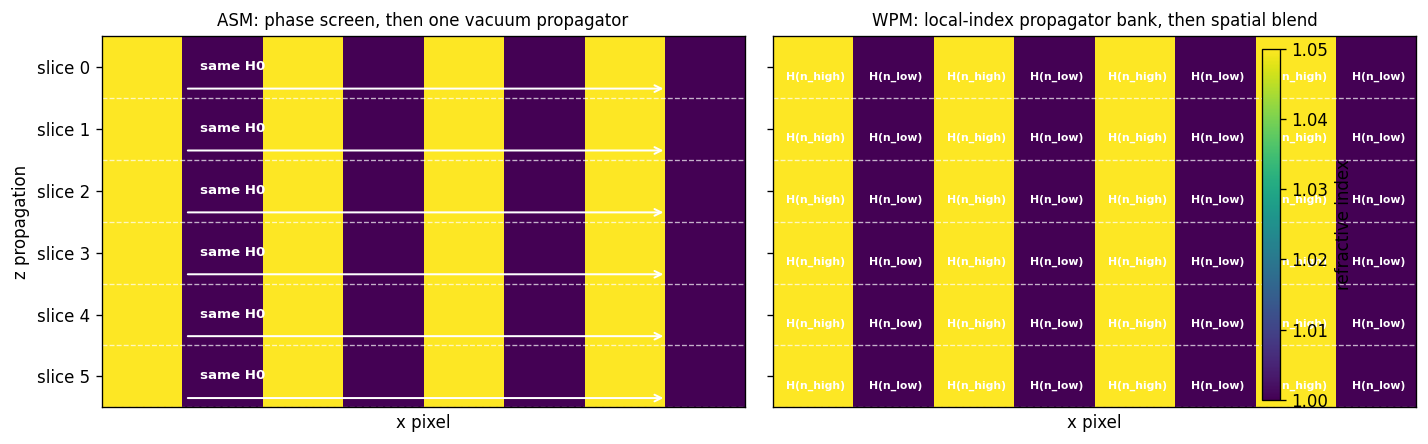

In [14]:
def plot_xz_schematic(n_low=1.0, n_high=1.05, period_px=16, n_slices=6):
    nx = 128
    x = np.arange(nx)
    n_1d = np.where(((x // period_px) % 2) == 0, n_high, n_low)
    n_xz = np.tile(n_1d, (n_slices, 1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
    titles = [
        "ASM: phase screen, then one vacuum propagator",
        "WPM: local-index propagator bank, then spatial blend",
    ]

    for ax, title in zip(axes, titles):
        im = ax.imshow(n_xz, aspect="auto", cmap="viridis", origin="upper")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("x pixel")
        ax.set_xticks([])
        ax.set_yticks(np.arange(n_slices))
        ax.set_yticklabels([f"slice {i}" for i in range(n_slices)])
        for y in np.arange(0.5, n_slices, 1.0):
            ax.axhline(y, color="white", lw=0.8, ls="--", alpha=0.7)

    for y in range(n_slices):
        axes[0].annotate("", xy=(112, y + 0.35), xytext=(16, y + 0.35), arrowprops=dict(arrowstyle="->", lw=1.2, color="white"))
        axes[0].text(19, y + 0.05, "same H0", color="white", fontsize=8, weight="bold")

    for y in range(n_slices):
        for x0 in range(0, nx, period_px):
            x_mid = x0 + 0.5 * period_px
            local_n = n_1d[min(nx - 1, int(x_mid))]
            label = "H(n_high)" if local_n > 0.5 * (n_low + n_high) else "H(n_low)"
            axes[1].text(x_mid, y + 0.2, label, color="white", fontsize=6.5, ha="center", weight="bold")

    axes[0].set_ylabel("z propagation")
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label="refractive index")
    fig.tight_layout()
    return fig


plot_xz_schematic(n_low, n_high, period_px=period_px, n_slices=6)
plt.show()

## 2D Synthetic Media

The same WPM machinery works for any transverse refractive-index map. We will use stripes for the main run because the two-material binning is especially easy to inspect.

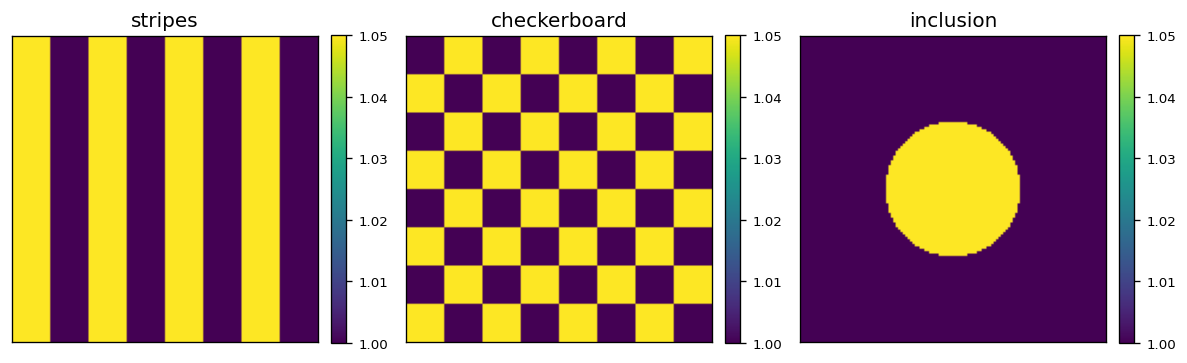

In [15]:
def plot_grid_gallery(shape, n_low, n_high, period_px):
    kinds = ["stripes", "checkerboard", "inclusion"]
    fig, axes = plt.subplots(1, len(kinds), figsize=(10, 3.2))
    for ax, kind in zip(axes, kinds):
        n_map = make_two_index_map(kind, shape, n_low, n_high, period_px)
        im = ax.imshow(as_numpy(n_map), cmap="viridis")
        ax.set_title(kind)
        ax.set_xticks([])
        ax.set_yticks([])
        add_colorbar(fig, ax, im)
    fig.tight_layout()
    return fig


plot_grid_gallery(shape, n_low, n_high, period_px)
plt.show()

n_map = make_two_index_map(pattern_kind, shape, n_low, n_high, period_px)
probe = make_tilted_gaussian_probe(shape, sampling, energy, probe_waist_A, probe_tilt_x_mrad)

## WPM Binning Diagnostics

With exactly two refractive-index values and `n_bins = 2`, WPM computes two homogeneous propagated fields: one for `n_low`, one for `n_high`. Each output pixel then selects the appropriate propagated field through the interpolation weight map.

WPM reference bins: [1.   1.05]
Unique weights: [0. 1.]


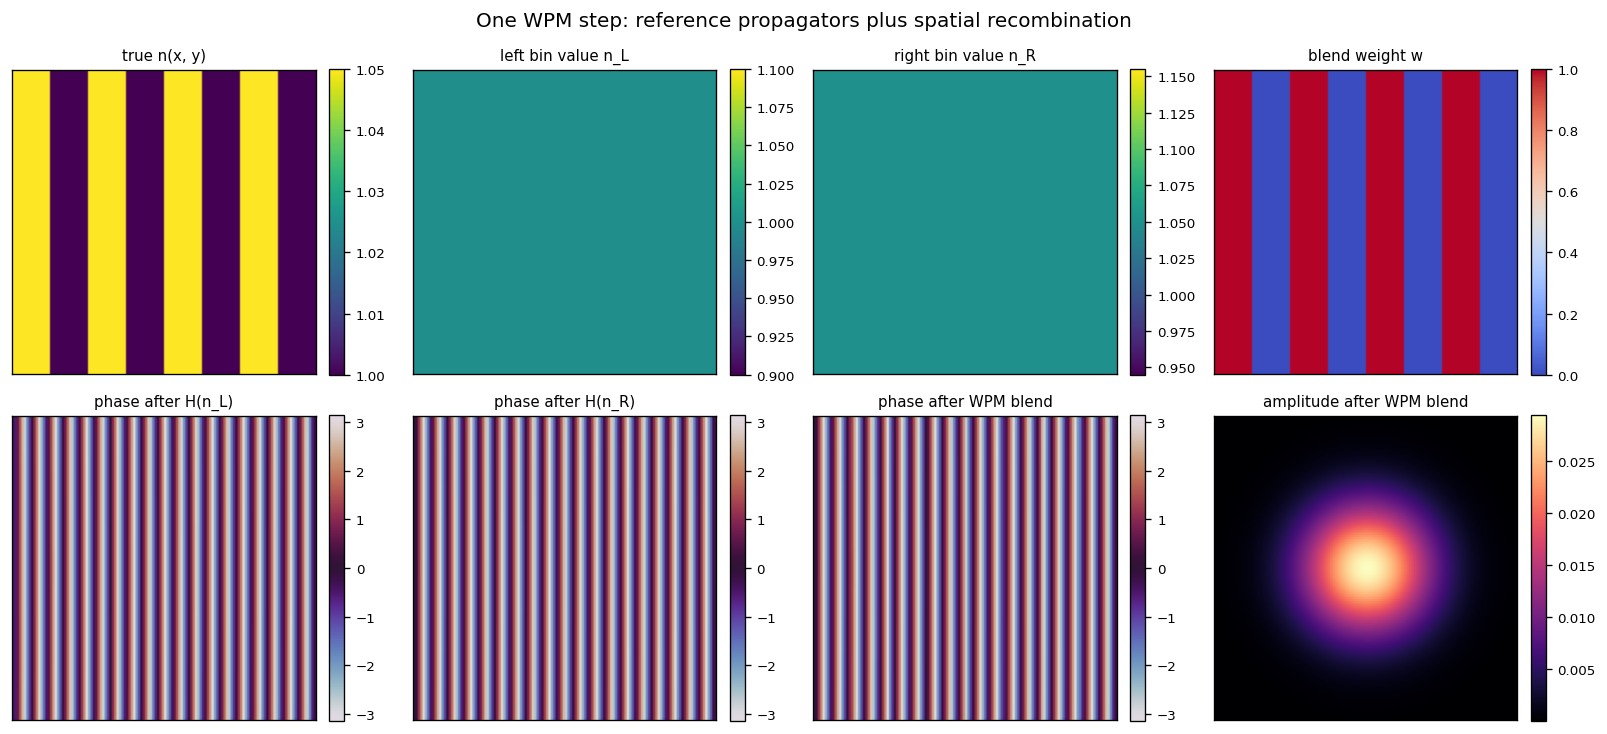

In [16]:
def plot_wpm_diagnostics(n_map, diagnostic):
    n_map_np = as_numpy(n_map)
    n_L = as_numpy(diagnostic["n_L"])
    n_R = as_numpy(diagnostic["n_R"])
    weights = as_numpy(diagnostic["weights"])
    field_L = as_numpy(diagnostic["field_L"])
    field_R = as_numpy(diagnostic["field_R"])
    wave = as_numpy(diagnostic["wave"])

    fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.2))
    panels = [
        (n_map_np, "true n(x, y)", "viridis", None),
        (n_L, "left bin value n_L", "viridis", None),
        (n_R, "right bin value n_R", "viridis", None),
        (weights, "blend weight w", "coolwarm", (0.0, 1.0)),
        (np.angle(field_L), "phase after H(n_L)", "twilight", (-np.pi, np.pi)),
        (np.angle(field_R), "phase after H(n_R)", "twilight", (-np.pi, np.pi)),
        (np.angle(wave), "phase after WPM blend", "twilight", (-np.pi, np.pi)),
        (np.abs(wave), "amplitude after WPM blend", "magma", None),
    ]

    for ax, (arr, title, cmap, limits) in zip(axes.ravel(), panels):
        kwargs = {}
        if limits is not None:
            kwargs.update(vmin=limits[0], vmax=limits[1])
        im = ax.imshow(arr, cmap=cmap, **kwargs)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        add_colorbar(fig, ax, im)

    fig.suptitle("One WPM step: reference propagators plus spatial recombination", fontsize=12)
    fig.tight_layout()
    return fig


diagnostic = wpm_diagnostic_step(probe, n_map, dz, energy, sampling, n_bins=n_bins, power_spacing=1.0)
print("WPM reference bins:", as_numpy(diagnostic["n_refs"]))
print("Unique weights:", np.unique(np.round(as_numpy(diagnostic["weights"]), 12)))
plot_wpm_diagnostics(n_map, diagnostic)
plt.show()

## ASM vs WPM After Several Slices

Now we propagate the same tilted Gaussian wave through the same static two-index map for a small number of slices. The two methods only differ in the propagation step: ASM uses a local phase screen followed by the vacuum angular-spectrum kernel, while WPM uses the local-index propagation bank.

In [17]:
exit_as, exit_wpm, as_history, wpm_history = run_stack(
    n_map, probe, dz, energy, sampling, n_slices=n_slices, n_bins=n_bins
)
jax.block_until_ready(exit_wpm)

as_aligned = align_global_phase(exit_as, exit_wpm)
wpm_np = as_numpy(exit_wpm)
diff_wave = wpm_np - as_aligned
phase_diff = np.angle(wpm_np * np.conj(as_aligned))

print(f"Exit-wave relative L2 difference, global phase aligned: {np.linalg.norm(diff_wave) / np.linalg.norm(wpm_np):.4e}")

Exit-wave relative L2 difference, global phase aligned: 2.5721e-01


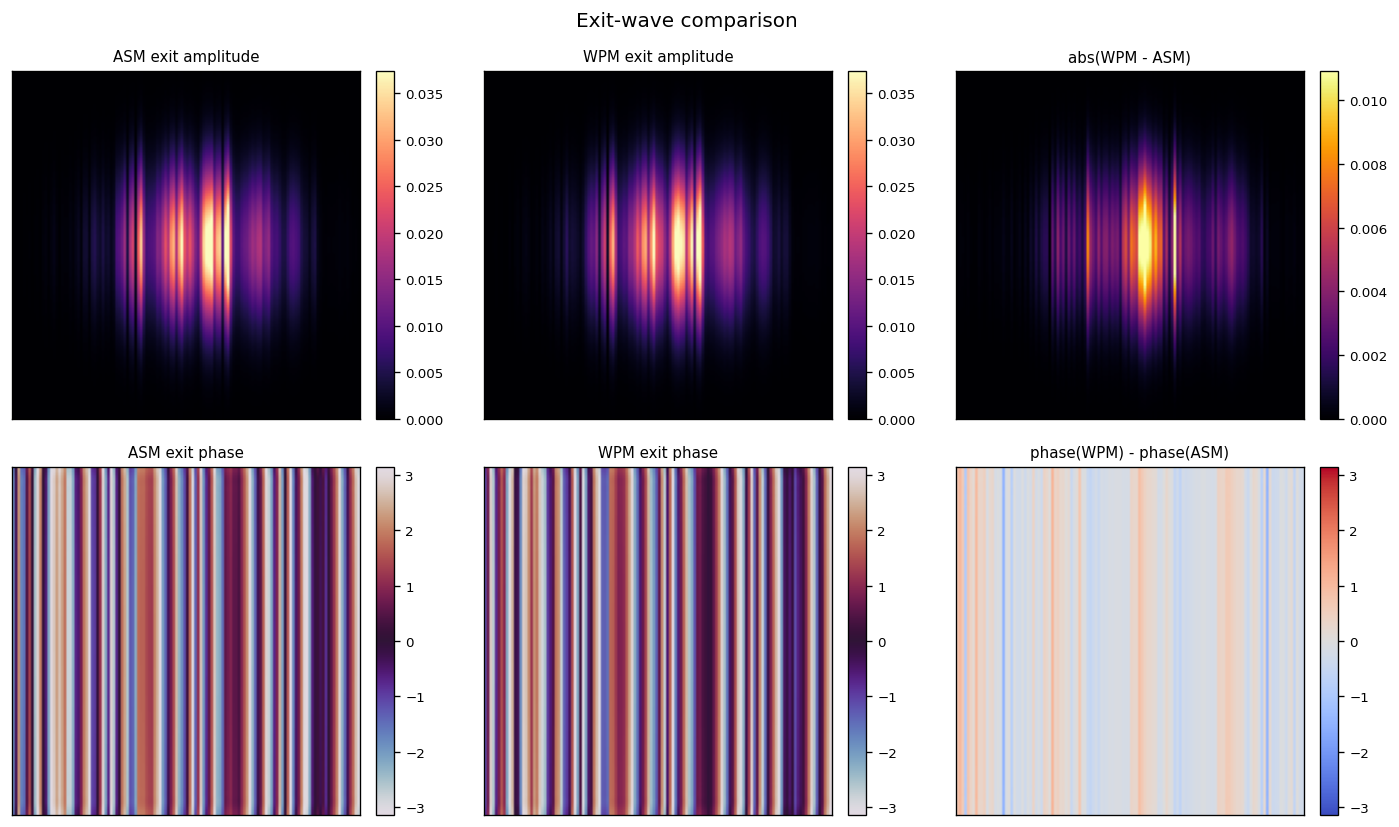

In [18]:
def plot_exit_comparison(exit_as, exit_wpm):
    as_aligned = align_global_phase(exit_as, exit_wpm)
    wpm = as_numpy(exit_wpm)
    diff = wpm - as_aligned
    phase_diff = np.angle(wpm * np.conj(as_aligned))

    amp_lim = max(np.percentile(np.abs(wpm), 99.5), np.percentile(np.abs(as_aligned), 99.5))
    diff_lim = max(np.percentile(np.abs(diff), 99.5), 1e-14)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    panels = [
        (np.abs(as_aligned), "ASM exit amplitude", "magma", (0.0, amp_lim)),
        (np.abs(wpm), "WPM exit amplitude", "magma", (0.0, amp_lim)),
        (np.abs(diff), "abs(WPM - ASM)", "inferno", (0.0, diff_lim)),
        (np.angle(as_aligned), "ASM exit phase", "twilight", (-np.pi, np.pi)),
        (np.angle(wpm), "WPM exit phase", "twilight", (-np.pi, np.pi)),
        (phase_diff, "phase(WPM) - phase(ASM)", "coolwarm", (-np.pi, np.pi)),
    ]

    for ax, (arr, title, cmap, limits) in zip(axes.ravel(), panels):
        im = ax.imshow(arr, cmap=cmap, vmin=limits[0], vmax=limits[1])
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        add_colorbar(fig, ax, im)

    fig.suptitle("Exit-wave comparison", fontsize=12)
    fig.tight_layout()
    return fig


plot_exit_comparison(exit_as, exit_wpm)
plt.show()

## Diffraction-Space View

The method gap is often easiest to interpret in Fourier space. WPM changes how high transverse-frequency components accumulate phase inside the medium, so the difference tends to live away from the central beam when the example is sufficiently high angle.

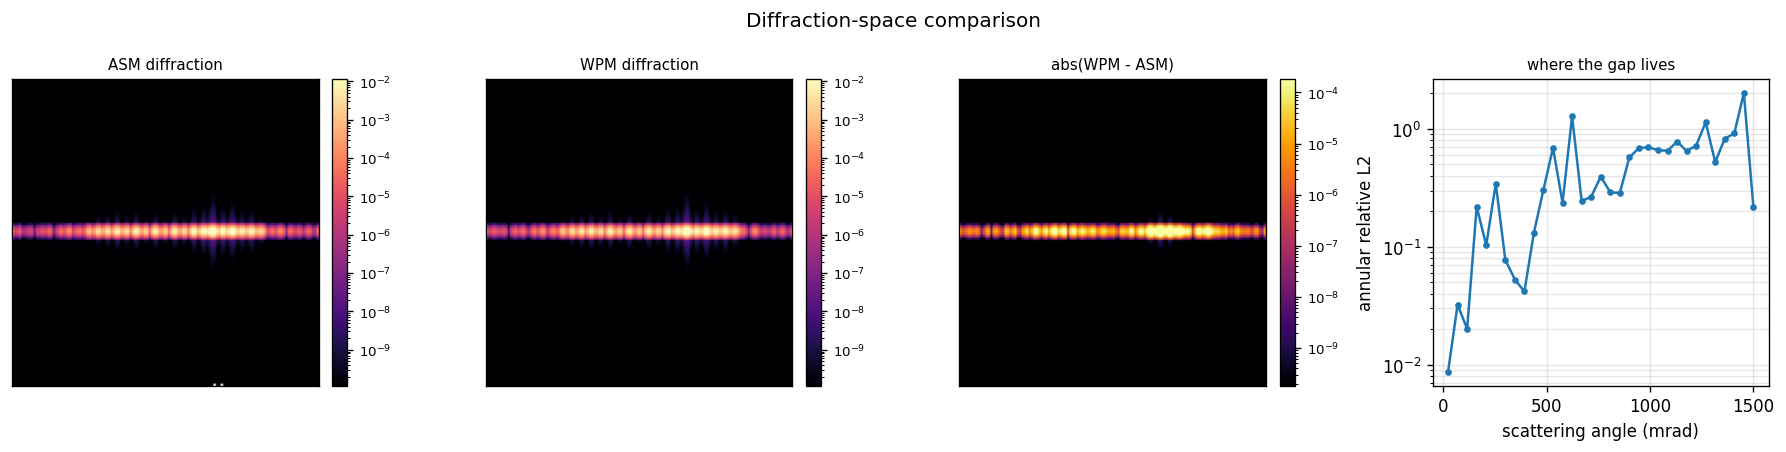

In [19]:
def plot_diffraction_comparison(exit_as, exit_wpm, sampling, energy):
    dp_as = diffraction_intensity(exit_as)
    dp_wpm = diffraction_intensity(exit_wpm)
    abs_diff = np.abs(dp_wpm - dp_as)

    positive = np.concatenate([dp_as[dp_as > 0], dp_wpm[dp_wpm > 0]])
    vmax = max(np.percentile(positive, 99.9), 1e-18)
    vmin = max(vmax * 1e-8, 1e-20)
    diff_vmax = max(np.percentile(abs_diff[abs_diff > 0], 99.5) if np.any(abs_diff > 0) else 1e-18, 1e-18)

    theta = angle_grid_mrad(dp_as.shape, sampling, energy)
    centers, ring_gap = annular_relative_l2(dp_as, dp_wpm, theta)

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
    panels = [
        (dp_as, "ASM diffraction", "magma", LogNorm(vmin=vmin, vmax=vmax)),
        (dp_wpm, "WPM diffraction", "magma", LogNorm(vmin=vmin, vmax=vmax)),
        (abs_diff, "abs(WPM - ASM)", "inferno", LogNorm(vmin=max(diff_vmax * 1e-6, 1e-20), vmax=diff_vmax)),
    ]

    for ax, (arr, title, cmap, norm) in zip(axes[:3], panels):
        im = ax.imshow(arr, cmap=cmap, norm=norm)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        add_colorbar(fig, ax, im)

    axes[3].semilogy(centers, ring_gap, "o-", ms=3)
    axes[3].set_xlabel("scattering angle (mrad)")
    axes[3].set_ylabel("annular relative L2")
    axes[3].set_title("where the gap lives", fontsize=9)
    axes[3].grid(True, which="both", alpha=0.3)

    fig.suptitle("Diffraction-space comparison", fontsize=12)
    fig.tight_layout()
    return fig


plot_diffraction_comparison(exit_as, exit_wpm, sampling, energy)
plt.show()

## Optional Smooth Boundary With More Bins

The clean two-material case uses weights of exactly 0 or 1. For continuously varying electron potentials, WPM uses a finite refractive-index grid and smooth interpolation between neighboring bins. This small smoothed-boundary example shows the same diagnostic view with `n_bins = 8`.

Smooth-map WPM reference bins:
[1.      1.00714 1.01429 1.02143 1.02857 1.03571 1.04286 1.05   ]
weight range: 0.000 to 1.000


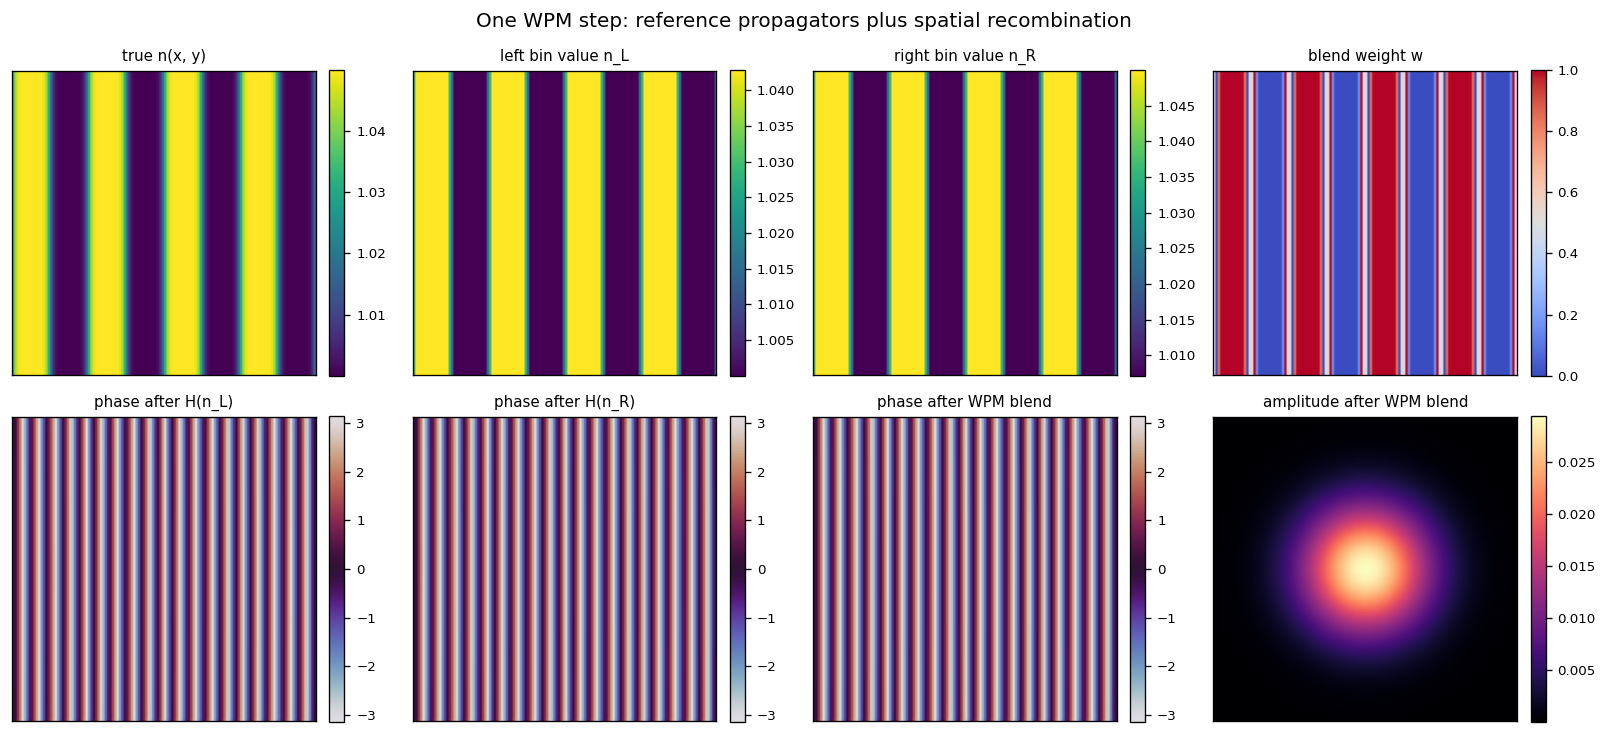

In [20]:
n_map_smooth = box_blur_periodic(n_map, passes=8)
diagnostic_smooth = wpm_diagnostic_step(
    probe, n_map_smooth, dz, energy, sampling, n_bins=8, power_spacing=1.0
)

print("Smooth-map WPM reference bins:")
print(np.array2string(as_numpy(diagnostic_smooth["n_refs"]), precision=5))
print(f"weight range: {as_numpy(diagnostic_smooth['weights']).min():.3f} to {as_numpy(diagnostic_smooth['weights']).max():.3f}")

plot_wpm_diagnostics(n_map_smooth, diagnostic_smooth)
plt.show()

## Sanity Checks

These checks are small and deterministic. They make sure the notebook examples agree with the expected limiting cases.

In [21]:
check_shape = (64, 64)
check_sampling = (0.15, 0.15)
check_probe = make_tilted_gaussian_probe(check_shape, check_sampling, energy, waist_A=1.8, tilt_x_mrad=160.0)

vacuum_n = jnp.ones(check_shape, dtype=jnp.float64)
as_vac = asm_step_local_n(check_probe, vacuum_n, dz, energy, check_sampling)
wpm_vac, _, _, _ = wpm_step_adaptive(check_probe, vacuum_n, dz, energy, check_sampling, n_bins=2, power_spacing=1.0)
vacuum_error = relative_l2(as_vac, wpm_vac)
assert vacuum_error < 1e-9, f"Vacuum ASM/WPM mismatch: {vacuum_error:.3e}"

uniform_n = n_high * jnp.ones(check_shape, dtype=jnp.float64)
wpm_uniform, _, _, _ = wpm_step_adaptive(check_probe, uniform_n, dz, energy, check_sampling, n_bins=2, power_spacing=1.0)
expected_uniform = homogeneous_wpm_field(check_probe, n_high, dz, energy, check_sampling)
uniform_error = relative_l2(wpm_uniform, expected_uniform)
assert uniform_error < 1e-9, f"Uniform-medium WPM mismatch: {uniform_error:.3e}"

two_index_n = make_two_index_map("checkerboard", check_shape, n_low, n_high, period_px=8)
_, weights, _, _ = wpm_step_adaptive(check_probe, two_index_n, dz, energy, check_sampling, n_bins=2, power_spacing=1.0)
weights_np = as_numpy(weights)
clean_weights = np.isclose(weights_np, 0.0, atol=1e-12) | np.isclose(weights_np, 1.0, atol=1e-12)
assert np.all(clean_weights), "Two-index, two-bin WPM weights should be exactly 0 or 1."

print(f"Vacuum ASM/WPM relative L2: {vacuum_error:.2e}")
print(f"Uniform WPM/expected homogeneous relative L2: {uniform_error:.2e}")
print("Two-index weights are clean 0/1 selections.")

Vacuum ASM/WPM relative L2: 1.55e-15
Uniform WPM/expected homogeneous relative L2: 0.00e+00
Two-index weights are clean 0/1 selections.


## Takeaways

- WPM reduces to the angular-spectrum behavior in vacuum and to a single homogeneous angular-spectrum propagation in a uniform medium.
- WPM is more expensive than ASM because it evaluates a bank of homogeneous propagators, one per refractive-index bin, then recombines them spatially.
- WPM can improve on ASM when propagation should occur inside a laterally varying refractive-index medium rather than through vacuum after a phase screen.
- In realistic electron microscopy examples the WPM and ASM difference may be small; this notebook deliberately amplifies the mechanism so the approximation is visible.